In [19]:
def single_neuron_forward(inputs, weights, bias):
   
    return sum(w * x for w, x in zip(weights, inputs)) + bias


class Neuron:

    def __init__(self, weights, bias):
        self.weights = list(weights)
        self.bias = float(bias)
        
    def forward(self, inputs):
       
        return sum(w * x for w, x in zip(self.weights, inputs)) + self.bias
        
    def __repr__(self):
        return f"Neuron(weights={self.weights}, bias={self.bias})"


x_test = [2.0, 3.0]
w_test = [0.8, -0.5]
b_test = 1.0


output_func = single_neuron_forward(x_test, w_test, b_test)


neuron_obj = Neuron(w_test, b_test)
output_oop = neuron_obj.forward(x_test)

print("--- Görev 1: Tek Nöron Forward Pass ---")
print(f"Girdiler (x)                  : {x_test}")
print(f"Ağırlıklar (w)               : {w_test}")
print(f"Bias (b)                     : {b_test}")
print(f"Fonksiyonel Çıktı (single_fn): {output_func:.4f}")
print(f"OOP Class Çıktısı (Neuron)   : {output_oop:.4f}")


--- Görev 1: Tek Nöron Forward Pass ---
Girdiler (x)                  : [2.0, 3.0]
Ağırlıklar (w)               : [0.8, -0.5]
Bias (b)                     : 1.0
Fonksiyonel Çıktı (single_fn): 1.1000
OOP Class Çıktısı (Neuron)   : 1.1000


In [15]:
def layer_forward(inputs, weights_list, biases):
   
    outputs = []
    for weights, bias in zip(weights_list, biases):
        neuron_out = single_neuron_forward(inputs, weights, bias)
        outputs.append(neuron_out)
    return outputs


class Layer:
   
    def __init__(self, neurons=None):
        self.neurons = list(neurons) if neurons else []
        
    def add_neuron(self, neuron):
        self.neurons.append(neuron)
        
    def forward(self, inputs):
        
        return [neuron.forward(inputs) for neuron in self.neurons]
        
    def __repr__(self):
        return f"Layer(num_neurons={len(self.neurons)})"


inputs = [2.0, 3.0]
weights_list = [
    [0.8, -0.5],   # 1. Nöron
    [0.2, 0.9],    # 2. Nöron
    [-0.4, 0.6]    # 3. Nöron
]
biases = [1.0, -0.5, 0.2]


layer_outputs_func = layer_forward(inputs, weights_list, biases)


neurons = [Neuron(w, b) for w, b in zip(weights_list, biases)]
layer_obj = Layer(neurons)
layer_outputs_oop = layer_obj.forward(inputs)

print("--- Görev 2: Katman Forward Pass ---")
print(f"Ortak Girdiler                 : {inputs}")
print(f"Fonksiyonel Katman Çıktısı     : {layer_outputs_func}")
print(f"OOP Layer Class Çıktısı        : {layer_outputs_oop}")
print(f"Oluşturulan Katman Nesnesi    : {layer_obj}")


--- Görev 2: Katman Forward Pass ---
Ortak Girdiler                 : [2.0, 3.0]
Fonksiyonel Katman Çıktısı     : [1.1, 2.6, 1.1999999999999997]
OOP Layer Class Çıktısı        : [1.1, 2.6, 1.1999999999999997]
Oluşturulan Katman Nesnesi    : Layer(num_neurons=3)


In [16]:
# 1. Tek Nöron İçin Loss Fonksiyonu
def single_neuron_loss(y_pred, y_true):
    
    return (y_pred - y_true) ** 2

# 2. Birden Fazla Nöron (Katman) İçin Loss Fonksiyonu
def multi_neuron_layer_loss(y_preds, y_trues):
   
    total_squared_error = sum((p - t) ** 2 for p, t in zip(y_preds, y_trues))
    return total_squared_error / len(y_trues)

# 3. Genel Esnek Loss Fonksiyonu (Hem Tek Hem Çoklu Nöron Destekli)
def mse_loss(y_pred, y_true):
   
    if isinstance(y_pred, (int, float)) and isinstance(y_true, (int, float)):
        return single_neuron_loss(y_pred, y_true)
    return multi_neuron_layer_loss(y_pred, y_true)

# --- Test Senaryoları ---

# A) TEK NÖRON İÇİN LOSS HESABI
pred_single = single_neuron_forward([2.0, 3.0], [0.8, -0.5], 1.0) # 1.1
target_single = 5.0

loss_single_explicit = single_neuron_loss(pred_single, target_single)

print("--- Görev 3: Loss (Kayıp) Hesaplama ---")
print("[1] TEK NÖRON İÇİN LOSS HESABI:")
print(f"    Tek Nöron Tahmini (y_pred) : {pred_single:.4f}")
print(f"    Gerçek Hedef (y_true)      : {target_single:.4f}")
print(f"    Kayıp (single_neuron_loss)  : {loss_single_explicit:.4f}")
print()


inputs = [2.0, 3.0]
weights_list = [
    [0.8, -0.5],   # 1. Nöron
    [0.2, 0.9],    # 2. Nöron
    [-0.4, 0.6]    # 3. Nöron
]
biases = [1.0, -0.5, 0.2]


layer_preds = layer_forward(inputs, weights_list, biases) # [1.1, 2.6, 1.2]

target_layer = [5.0, 3.0, 2.0]

loss_layer_explicit = multi_neuron_layer_loss(layer_preds, target_layer)

print("[2] BİRDEN FAZLA NÖRON (KATMAN) İÇİN LOSS HESABI:")
print(f"    Katman Tahminleri (y_preds)      : {[round(p, 4) for p in layer_preds]}")
print(f"    Gerçek Hedefler (y_trues)        : {target_layer}")
print(f"    Kayıp (multi_neuron_layer_loss) : {loss_layer_explicit:.4f}")


--- Görev 3: Loss (Kayıp) Hesaplama ---
[1] TEK NÖRON İÇİN LOSS HESABI:
    Tek Nöron Tahmini (y_pred) : 1.1000
    Gerçek Hedef (y_true)      : 5.0000
    Kayıp (single_neuron_loss)  : 15.2100

[2] BİRDEN FAZLA NÖRON (KATMAN) İÇİN LOSS HESABI:
    Katman Tahminleri (y_preds)      : [1.1, 2.6, 1.2]
    Gerçek Hedefler (y_trues)        : [5.0, 3.0, 2.0]
    Kayıp (multi_neuron_layer_loss) : 5.3367


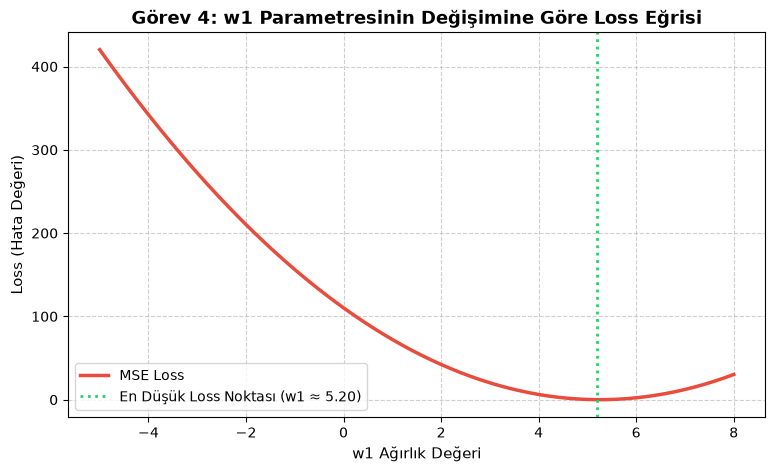

--- Görev 4 Sonucu ---
Gözlemlenen en düşük loss değeri: 0.0100 (w1 = 5.20 için)


In [17]:
import matplotlib.pyplot as plt


x_input = [2.0, 3.0]
w2_fixed = -0.5
b_fixed = 1.0
target = 10.0  


w1_range = [w1_int / 10.0 for w1_int in range(-50, 81)] # [-5.0, -4.9, ..., 8.0]
loss_list = []

for w1 in w1_range:
    # Forward Pass
    current_pred = single_neuron_forward(x_input, [w1, w2_fixed], b_fixed)
    # Loss Hesabı
    current_loss = mse_loss(current_pred, target)
    loss_list.append(current_loss)

# Loss Eğrisini Çizdirelim
plt.figure(figsize=(9, 5))
plt.plot(w1_range, loss_list, color='#e74c3c', linewidth=2.5, label='MSE Loss')
plt.title("Görev 4: w1 Parametresinin Değişimine Göre Loss Eğrisi", fontsize=13, fontweight='bold')
plt.xlabel("w1 Ağırlık Değeri", fontsize=11)
plt.ylabel("Loss (Hata Değeri)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Minimum noktasını vurgulayalım
min_loss = min(loss_list)
best_w1 = w1_range[loss_list.index(min_loss)]
plt.axvline(x=best_w1, color='#2ecc71', linestyle=':', linewidth=2, label=f'En Düşük Loss Noktası (w1 ≈ {best_w1:.2f})')

plt.legend(fontsize=10)
plt.show()

print("--- Görev 4 Sonucu ---")
print(f"Gözlemlenen en düşük loss değeri: {min_loss:.4f} (w1 = {best_w1:.2f} için)")


--- Görev 5: Gradient Descent Eğitimi Başlıyor ---
Başlangıç Parametreleri -> w: [0.0, 0.0], b: 0.0
Başlangıç Tahmini       -> 0.0000 (Hedef: 10.0)

Epoch  0 | Loss: 100.0000 | Tahmin: 5.6000 | w1: 0.8000, w2: 1.2000, b: 0.4000
Epoch  5 | Loss:   0.0272 | Tahmin: 9.9274 | w1: 1.4182, w2: 2.1273, b: 0.7091
Epoch 10 | Loss:   0.0000 | Tahmin: 9.9988 | w1: 1.4284, w2: 2.1426, b: 0.7142
Epoch 15 | Loss:   0.0000 | Tahmin: 10.0000 | w1: 1.4286, w2: 2.1428, b: 0.7143
Epoch 20 | Loss:   0.0000 | Tahmin: 10.0000 | w1: 1.4286, w2: 2.1428, b: 0.7143
Epoch 25 | Loss:   0.0000 | Tahmin: 10.0000 | w1: 1.4286, w2: 2.1428, b: 0.7143
Epoch 30 | Loss:   0.0000 | Tahmin: 10.0000 | w1: 1.4286, w2: 2.1428, b: 0.7143
Epoch 35 | Loss:   0.0000 | Tahmin: 10.0000 | w1: 1.4286, w2: 2.1428, b: 0.7143
Epoch 39 | Loss:   0.0000 | Tahmin: 10.0000 | w1: 1.4286, w2: 2.1428, b: 0.7143

--- Eğitim Tamamlandı ---
Son Parametreler -> w1: 1.4286, w2: 2.1428, b: 0.7143
Son Tahmin      -> 10.0000 (Hedef: 10.0)
Son Loss    

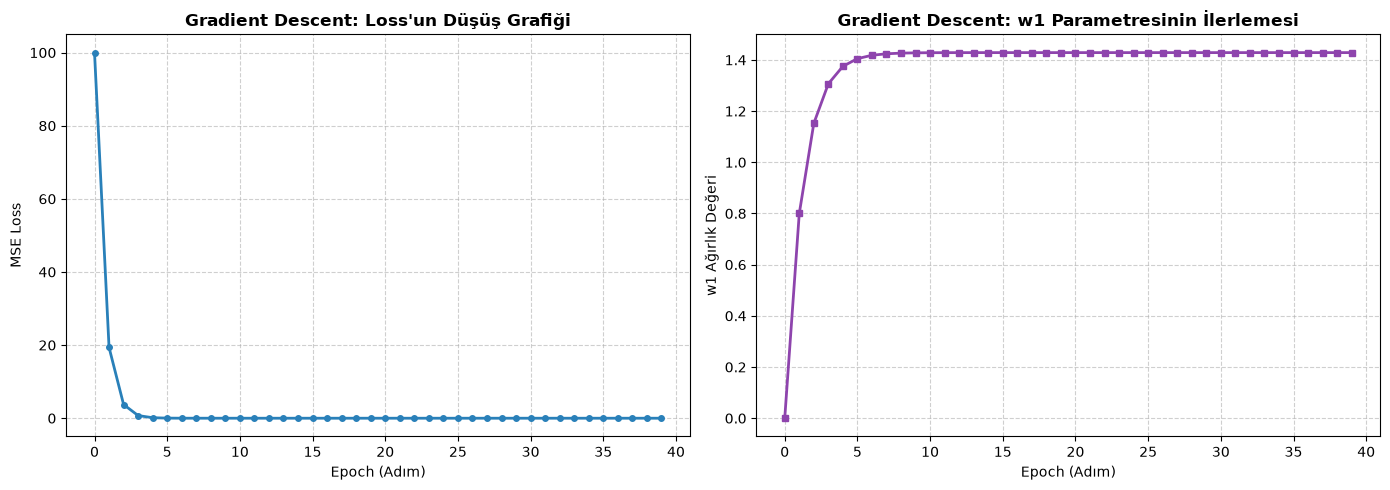

In [18]:
def compute_numerical_gradients(inputs, weights, bias, y_true, h=1e-5):
  
   
    base_pred = single_neuron_forward(inputs, weights, bias)
    base_loss = mse_loss(base_pred, y_true)
    
   
    grad_weights = []
    for i in range(len(weights)):
        weights_perturbed = list(weights)
        weights_perturbed[i] += h  # wi parametresine küçük h ekliyoruz
        
        pred_perturbed = single_neuron_forward(inputs, weights_perturbed, bias)
        loss_perturbed = mse_loss(pred_perturbed, y_true)
        
        # Sayısal türev formülü: (L(w + h) - L(w)) / h
        dw_i = (loss_perturbed - base_loss) / h
        grad_weights.append(dw_i)
        
    # 3. Bias için gradyan hesabı: dL/db
    bias_perturbed = bias + h
    pred_b_perturbed = single_neuron_forward(inputs, weights, bias_perturbed)
    loss_b_perturbed = mse_loss(pred_b_perturbed, y_true)
    db = (loss_b_perturbed - base_loss) / h
    
    return grad_weights, db, base_loss


inputs = [2.0, 3.0]
y_true = 10.0  


weights = [0.0, 0.0]
bias = 0.0

learning_rate = 0.02  
epochs = 40           

history_loss = []
history_w1 = []

print("--- Görev 5: Gradient Descent Eğitimi Başlıyor ---")
print(f"Başlangıç Parametreleri -> w: {weights}, b: {bias}")
print(f"Başlangıç Tahmini       -> {single_neuron_forward(inputs, weights, bias):.4f} (Hedef: {y_true})\n")

for epoch in range(epochs):
    
    grad_w, grad_b, current_loss = compute_numerical_gradients(inputs, weights, bias, y_true)
    

    history_loss.append(current_loss)
    history_w1.append(weights[0])
    

    for i in range(len(weights)):
        weights[i] -= learning_rate * grad_w[i]
    bias -= learning_rate * grad_b
    

    if epoch % 5 == 0 or epoch == epochs - 1:
        pred = single_neuron_forward(inputs, weights, bias)
        print(f"Epoch {epoch:2d} | Loss: {current_loss:8.4f} | Tahmin: {pred:6.4f} | w1: {weights[0]:.4f}, w2: {weights[1]:.4f}, b: {bias:.4f}")

final_pred = single_neuron_forward(inputs, weights, bias)
print("\n--- Eğitim Tamamlandı ---")
print(f"Son Parametreler -> w1: {weights[0]:.4f}, w2: {weights[1]:.4f}, b: {bias:.4f}")
print(f"Son Tahmin      -> {final_pred:.4f} (Hedef: {y_true})")
print(f"Son Loss        -> {mse_loss(final_pred, y_true):.6f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(range(epochs), history_loss, color='#2980b9', marker='o', markersize=4, linewidth=2)
ax1.set_title("Gradient Descent: Loss'un Düşüş Grafiği", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epoch (Adım)", fontsize=10)
ax1.set_ylabel("MSE Loss", fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(range(epochs), history_w1, color='#8e44ad', marker='s', markersize=4, linewidth=2)
ax2.set_title("Gradient Descent: w1 Parametresinin İlerlemesi", fontsize=12, fontweight='bold')
ax2.set_xlabel("Epoch (Adım)", fontsize=10)
ax2.set_ylabel("w1 Ağırlık Değeri", fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
